In [33]:
# import the required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing  import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [3]:
# import data set
df = pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# total number of patient
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


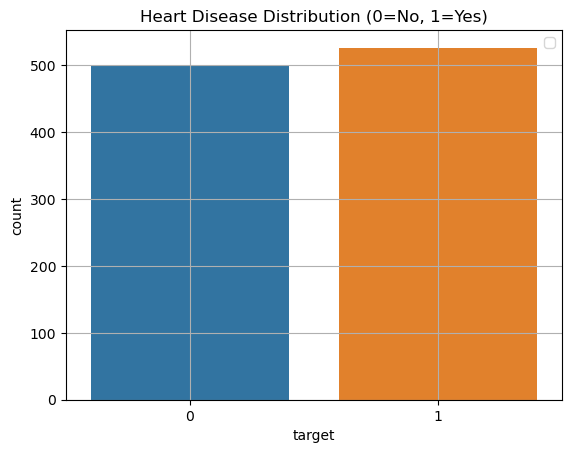

In [16]:
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution (0=No, 1=Yes)')
plt.legend()
plt.grid()
plt.show()

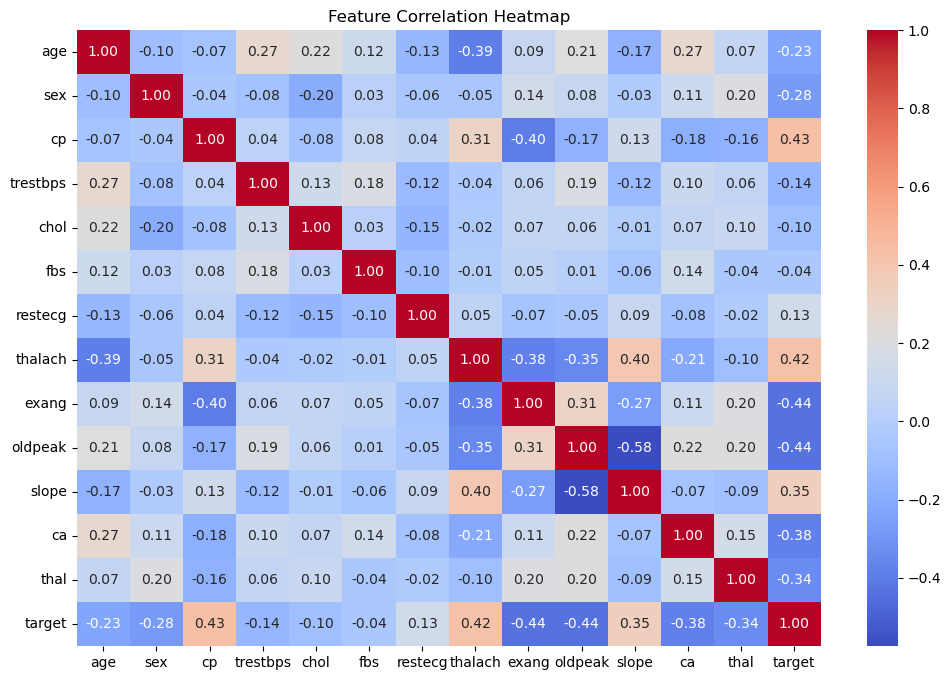

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [20]:
# split the data set into dependent var and independent var

x = df.drop('target',axis = 1)
y = df['target']
print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (1025, 13)
Target shape: (1025,)


In [24]:
# Split the dataset into training and testin set 

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [26]:
print(x_train.shape[0])
print( x_test.shape[0])

820
205


In [28]:
# perform the features scalling 

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [30]:
print("Mean of scaled training data (should be close to 0):")
print(x_train_scaled.mean(axis=0).round(2))

Mean of scaled training data (should be close to 0):
[-0.  0.  0.  0. -0. -0. -0.  0.  0. -0.  0.  0.  0.]


In [43]:
# train the ml models

# train random forest model
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 98.54%


In [40]:
# Train xboost model
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(x_train_scaled, y_train)
xgb_pred = xgb_model.predict(x_test_scaled)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred) * 100:.2f}%")

XGBoost Accuracy: 98.54%


In [39]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(x_train_scaled, y_train)
lr_pred = lr_model.predict(x_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred) * 100:.2f}%")

Logistic Regression Accuracy: 79.51%


In [46]:
xgb_train_pred = xgb_model.predict(x_train_scaled)
print(f"XGBoost Training Accuracy: {accuracy_score(y_train, xgb_train_pred) * 100:.2f}%")
print(f"XGBoost Testing Accuracy:  {accuracy_score(y_test, xgb_pred) * 100:.2f}%")

XGBoost Training Accuracy: 100.00%
XGBoost Testing Accuracy:  98.54%


In [47]:
cm = confusion_matrix(y_test, xgb_pred)
print(cm)

[[102   0]
 [  3 100]]


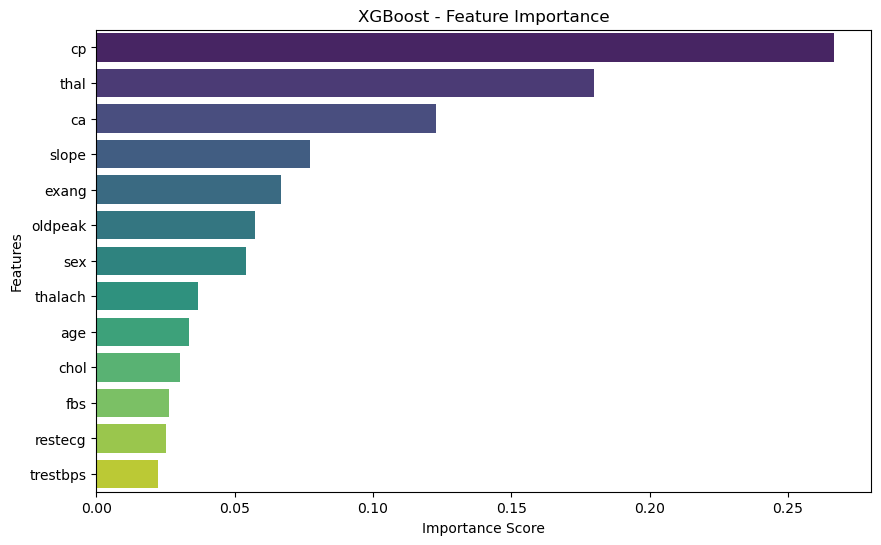

In [49]:
# plot features

feature_importance = pd.Series(xgb_model.feature_importances_, 
                                index=x.columns)
feature_importance_sorted = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_sorted.values, 
            y=feature_importance_sorted.index, 
            palette='viridis')
plt.title('XGBoost - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [51]:
# save the model and scaller

import joblib

joblib.dump(xgb_model, "heart_disease_model.pkl")
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [53]:
new_patient = pd.DataFrame({
    'age': [52],
    'sex': [1],
    'cp': [0],
    'trestbps': [125],
    'chol': [212],
    'fbs': [0],
    'restecg': [1],
    'thalach': [168],
    'exang': [0],
    'oldpeak': [1.0],
    'slope': [2],
    'ca': [2],
    'thal': [3]
})

In [54]:
new_patient_scaled = scaler.transform(new_patient)
prediction = xgb_model.predict(new_patient_scaled)
probability = xgb_model.predict_proba(new_patient_scaled)

print(f"Prediction: {'❤️ Heart Disease Detected' if prediction[0] == 1 else '✅ No Heart Disease'}")
print(f"Probability of Disease: {probability[0][1] * 100:.2f}%")
print(f"Probability of No Disease: {probability[0][0] * 100:.2f}%")

Prediction: ✅ No Heart Disease
Probability of Disease: 0.48%
Probability of No Disease: 99.52%
